# MODULE 3: Python Data Pipeline and EDA

This notebook handles loading the engineered features from MATLAB, performing data cleaning, standardizing dimensions, and exploring the data critically through visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

# Set unified plotting aesthetic
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load features.csv
data_path = '../../data/features/features.csv'
df = pd.read_csv(data_path)
display(df.head())

,time,mean,variance,energy,dominant_frequency,entropy,label
0,0.00,0.810571,0.147726,80.475192,0.0,4.734240,0
1,0.05,-0.068132,0.764586,76.922785,10.0,4.645849,0
2,0.10,-0.697982,0.520136,100.731488,10.0,4.802197,0
3,0.15,-0.070793,0.604520,60.953178,10.0,4.985076,0
4,0.20,0.777814,0.260940,86.593470,0.0,4.987440,0


In [2]:
# 2. Missing Value Handling & Standardization
print("Missing Values Per Column:")
print(df.isnull().sum())

# Handle missing values via forward fill
df.ffill(inplace=True)

features = ['mean', 'variance', 'energy', 'dominant_frequency', 'entropy']
X = df[features]
y = df['label']

# Fit and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['label'] = y
df_scaled['time'] = df['time']

print("\nData Processing Complete.")

Missing Values Per Column:
time                  0
mean                  0
variance              0
energy                0
dominant_frequency    0
entropy               0
label                 0
dtype: int64

Data Processing Complete.


Statistical Description of Scaled Features:


,mean,variance,energy,dominant_frequency,entropy
count,1.990000e+02,1.990000e+02,1.990000e+02,1.990000e+02,1.990000e+02
mean,1.785283e-17,-1.338962e-16,-3.124246e-17,-1.785283e-17,-1.664777e-15
std,1.002522e+00,1.002522e+00,1.002522e+00,1.002522e+00,1.002522e+00
min,-1.460491e+00,-1.612744e+00,-8.242518e-01,-1.301393e+00,-8.525757e+00
25%,-3.072455e-01,-8.341348e-01,-3.068889e-01,-1.301393e+00,-1.489037e-01
50%,-1.837744e-01,-6.691825e-02,-2.250129e-01,3.481434e-01,1.703542e-01
75%,7.565807e-01,5.613318e-01,-1.108875e-01,3.481434e-01,4.194782e-01
max,4.278492e+00,2.692471e+00,8.055991e+00,1.997680e+00,1.175948e+00


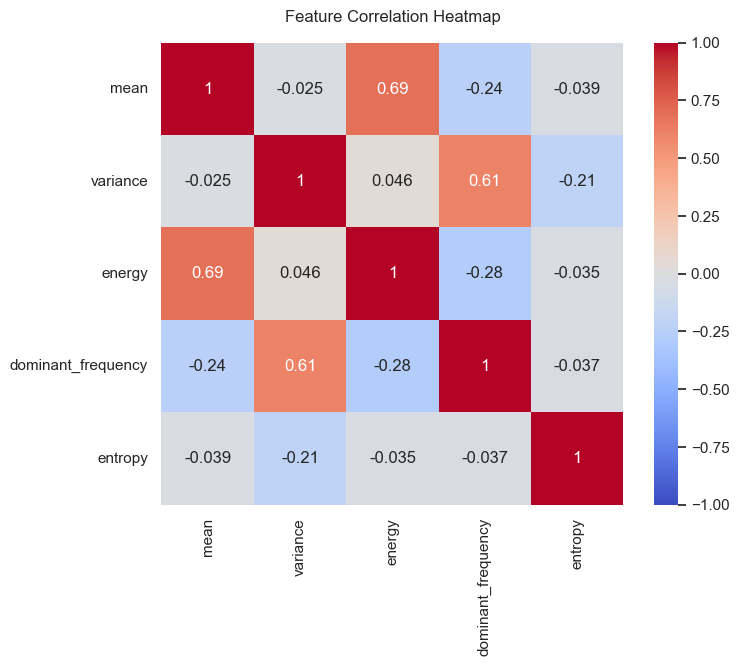

In [3]:
# Exploratory Data Analysis (EDA): Statistical Description
print("Statistical Description of Scaled Features:")
display(df_scaled[features].describe())

plt.figure(figsize=(8, 6))
corr = df_scaled[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Heatmap', pad=15)
plt.show()

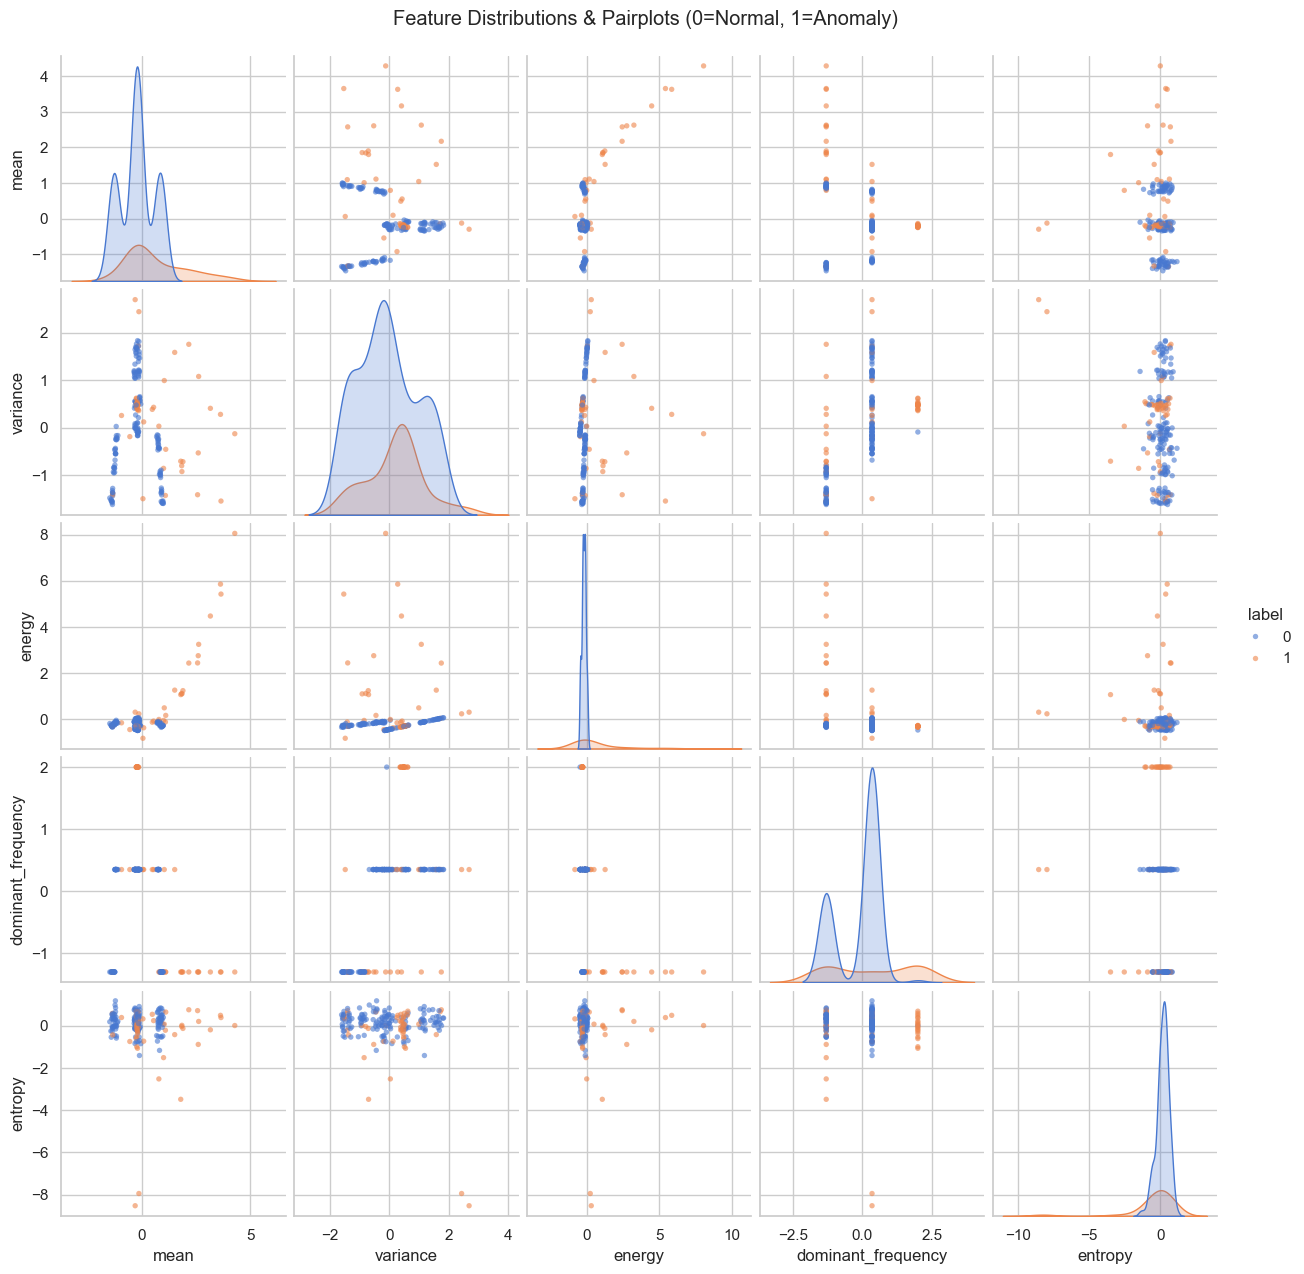

In [4]:
# 3. Visualize Feature Distributions & Relationships

# Using a pairplot to see how features separate anomalous patterns from normal ones
pairplot = sns.pairplot(
    df_scaled, 
    vars=features, 
    hue='label', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 15, 'edgecolor': 'none'}
)
pairplot.fig.suptitle('Feature Distributions & Pairplots (0=Normal, 1=Anomaly)', y=1.02)
plt.show()

In [5]:
# Save the perfectly prepared dataset for Module 4
out_dir = '../../data/processed'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'processed_features.csv')

df_scaled.to_csv(out_path, index=False)
print(f"Processed dataset effectively saved to: {out_path}")

Processed dataset effectively saved to: ../../data/processed/processed_features.csv
